# 05 — Edge-Weight Analysis

This notebook investigates the role of edge-weight representation and weight
diversity in the Max-Cut benchmark instances.

The analysis focuses on two main questions:

1. How are the benchmark instances distributed across different edge-weight
   categories, including integer-weighted, non-integer-weighted, and
   unique-weight-dominance groups?

2. How does the dominance of unique or repeated edge weights influence solver
   performance across DAv3c, DAv2, DAv3, and the selected MQLib heuristics?

In [112]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

#project imports
sys.path.append(str(Path("../src/maxcut").resolve()))

%load_ext autoreload
%autoreload 2

import config as cfg
import utils
import plotting
plotting.set_plot_style()
print(f"Figures will be saved to: {cfg.FIGURE_DIR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Figures will be saved to: /Users/sargun/Desktop/DAMB-DAv3c/results/figures


In [113]:
# Paths
PATH_BASELINE = (
    cfg.PROCESSED_DIR / "baseline_dataset.csv"
)

UW_PATH = (
    cfg.PROCESSED_DIR / "graph_uweight_dominance.csv"
)

In [114]:
df_unique_wt = pd.read_csv(UW_PATH)
len(df_unique_wt)

3506

In [115]:
df_unique_wt.head()

,name,nodes,edges,unique_weights,unique_weight_std,unique_weight_mean,unique_weight_cv,unique_weight_range,top1_weight_share,top5_weight_share,top10_weight_share,n_weights_50,n_weights_75,n_weights_90,n_weights_95,rare_weight_share_1pct,weight_frequency_category
0,G55,5000,12498,1,0.0,1.0,0.000000e+00,0.0,1.000000,1.0,1.0,1,1,1,1,0.0,uniform
1,G56,5000,12498,2,1.0,0.0,1.000000e+12,2.0,0.502160,1.0,1.0,1,2,2,2,0.0,few_weights_dominated
2,G57,5000,10000,2,1.0,0.0,1.000000e+12,2.0,0.501900,1.0,1.0,1,2,2,2,0.0,few_weights_dominated
3,G58,5000,29570,1,0.0,1.0,0.000000e+00,0.0,1.000000,1.0,1.0,1,1,1,1,0.0,uniform
4,G59,5000,29570,2,1.0,0.0,1.000000e+12,2.0,0.501623,1.0,1.0,1,2,2,2,0.0,few_weights_dominated


In [116]:
df_baseline = pd.read_csv(PATH_BASELINE)
df_baseline.head()

,name,nodes,edges,density,limit,has_leafs,int_only,size_cat,density_cat,heuristics_name,...,neg_edges_frac,neg_wt_sum,neg_wt_ratio,has_triangles,triangle_count,cyclomatic_number,transitivity,average_clustering,bridge_count,bridge_fraction
0,G55,4969,12498,0.001013,13.945,True,True,large,sparse,BURER2002,...,0.000000,0.0,0.000000,True,23,7530,0.001100,0.001189,180,0.014402
1,G56,4969,12498,0.001013,13.922,True,True,large,sparse,BURER2002,...,0.502160,-6276.0,0.502160,True,23,7530,0.001100,0.001189,180,0.014402
2,G57,5000,10000,0.000800,11.299,False,True,large,sparse,BURER2002,...,0.501900,-5019.0,0.501900,False,0,5001,0.000000,0.000000,0,0.000000
3,G58,5000,29570,0.002366,11.876,False,True,large,sparse,BURER2002,...,0.000000,0.0,0.000000,True,30784,24571,0.098091,0.326822,0,0.000000
4,G59,5000,29570,0.002366,15.875,False,True,large,sparse,BURER2002,...,0.498377,-14737.0,0.498377,True,30784,24571,0.098091,0.326822,0,0.000000


In [117]:
len(df_baseline)

3400

In [200]:
df_final = df_unique_wt.merge(df_baseline, on=["name"])

In [163]:
df_final.head()

,name,nodes_x,edges_x,unique_weights,unique_weight_std,unique_weight_mean,unique_weight_cv,unique_weight_range,top1_weight_share,top5_weight_share,...,neg_edges_frac,neg_wt_sum,neg_wt_ratio,has_triangles,triangle_count,cyclomatic_number,transitivity,average_clustering,bridge_count,bridge_fraction
0,G55,5000,12498,1,0.0,1.0,0.000000e+00,0.0,1.000000,1.0,...,0.000000,0.0,0.000000,True,23,7530,0.001100,0.001189,180,0.014402
1,G56,5000,12498,2,1.0,0.0,1.000000e+12,2.0,0.502160,1.0,...,0.502160,-6276.0,0.502160,True,23,7530,0.001100,0.001189,180,0.014402
2,G57,5000,10000,2,1.0,0.0,1.000000e+12,2.0,0.501900,1.0,...,0.501900,-5019.0,0.501900,False,0,5001,0.000000,0.000000,0,0.000000
3,G58,5000,29570,1,0.0,1.0,0.000000e+00,0.0,1.000000,1.0,...,0.000000,0.0,0.000000,True,30784,24571,0.098091,0.326822,0,0.000000
4,G59,5000,29570,2,1.0,0.0,1.000000e+12,2.0,0.501623,1.0,...,0.498377,-14737.0,0.498377,True,30784,24571,0.098091,0.326822,0,0.000000


In [164]:
df_filter = utils.filter_main_instances(df_final)

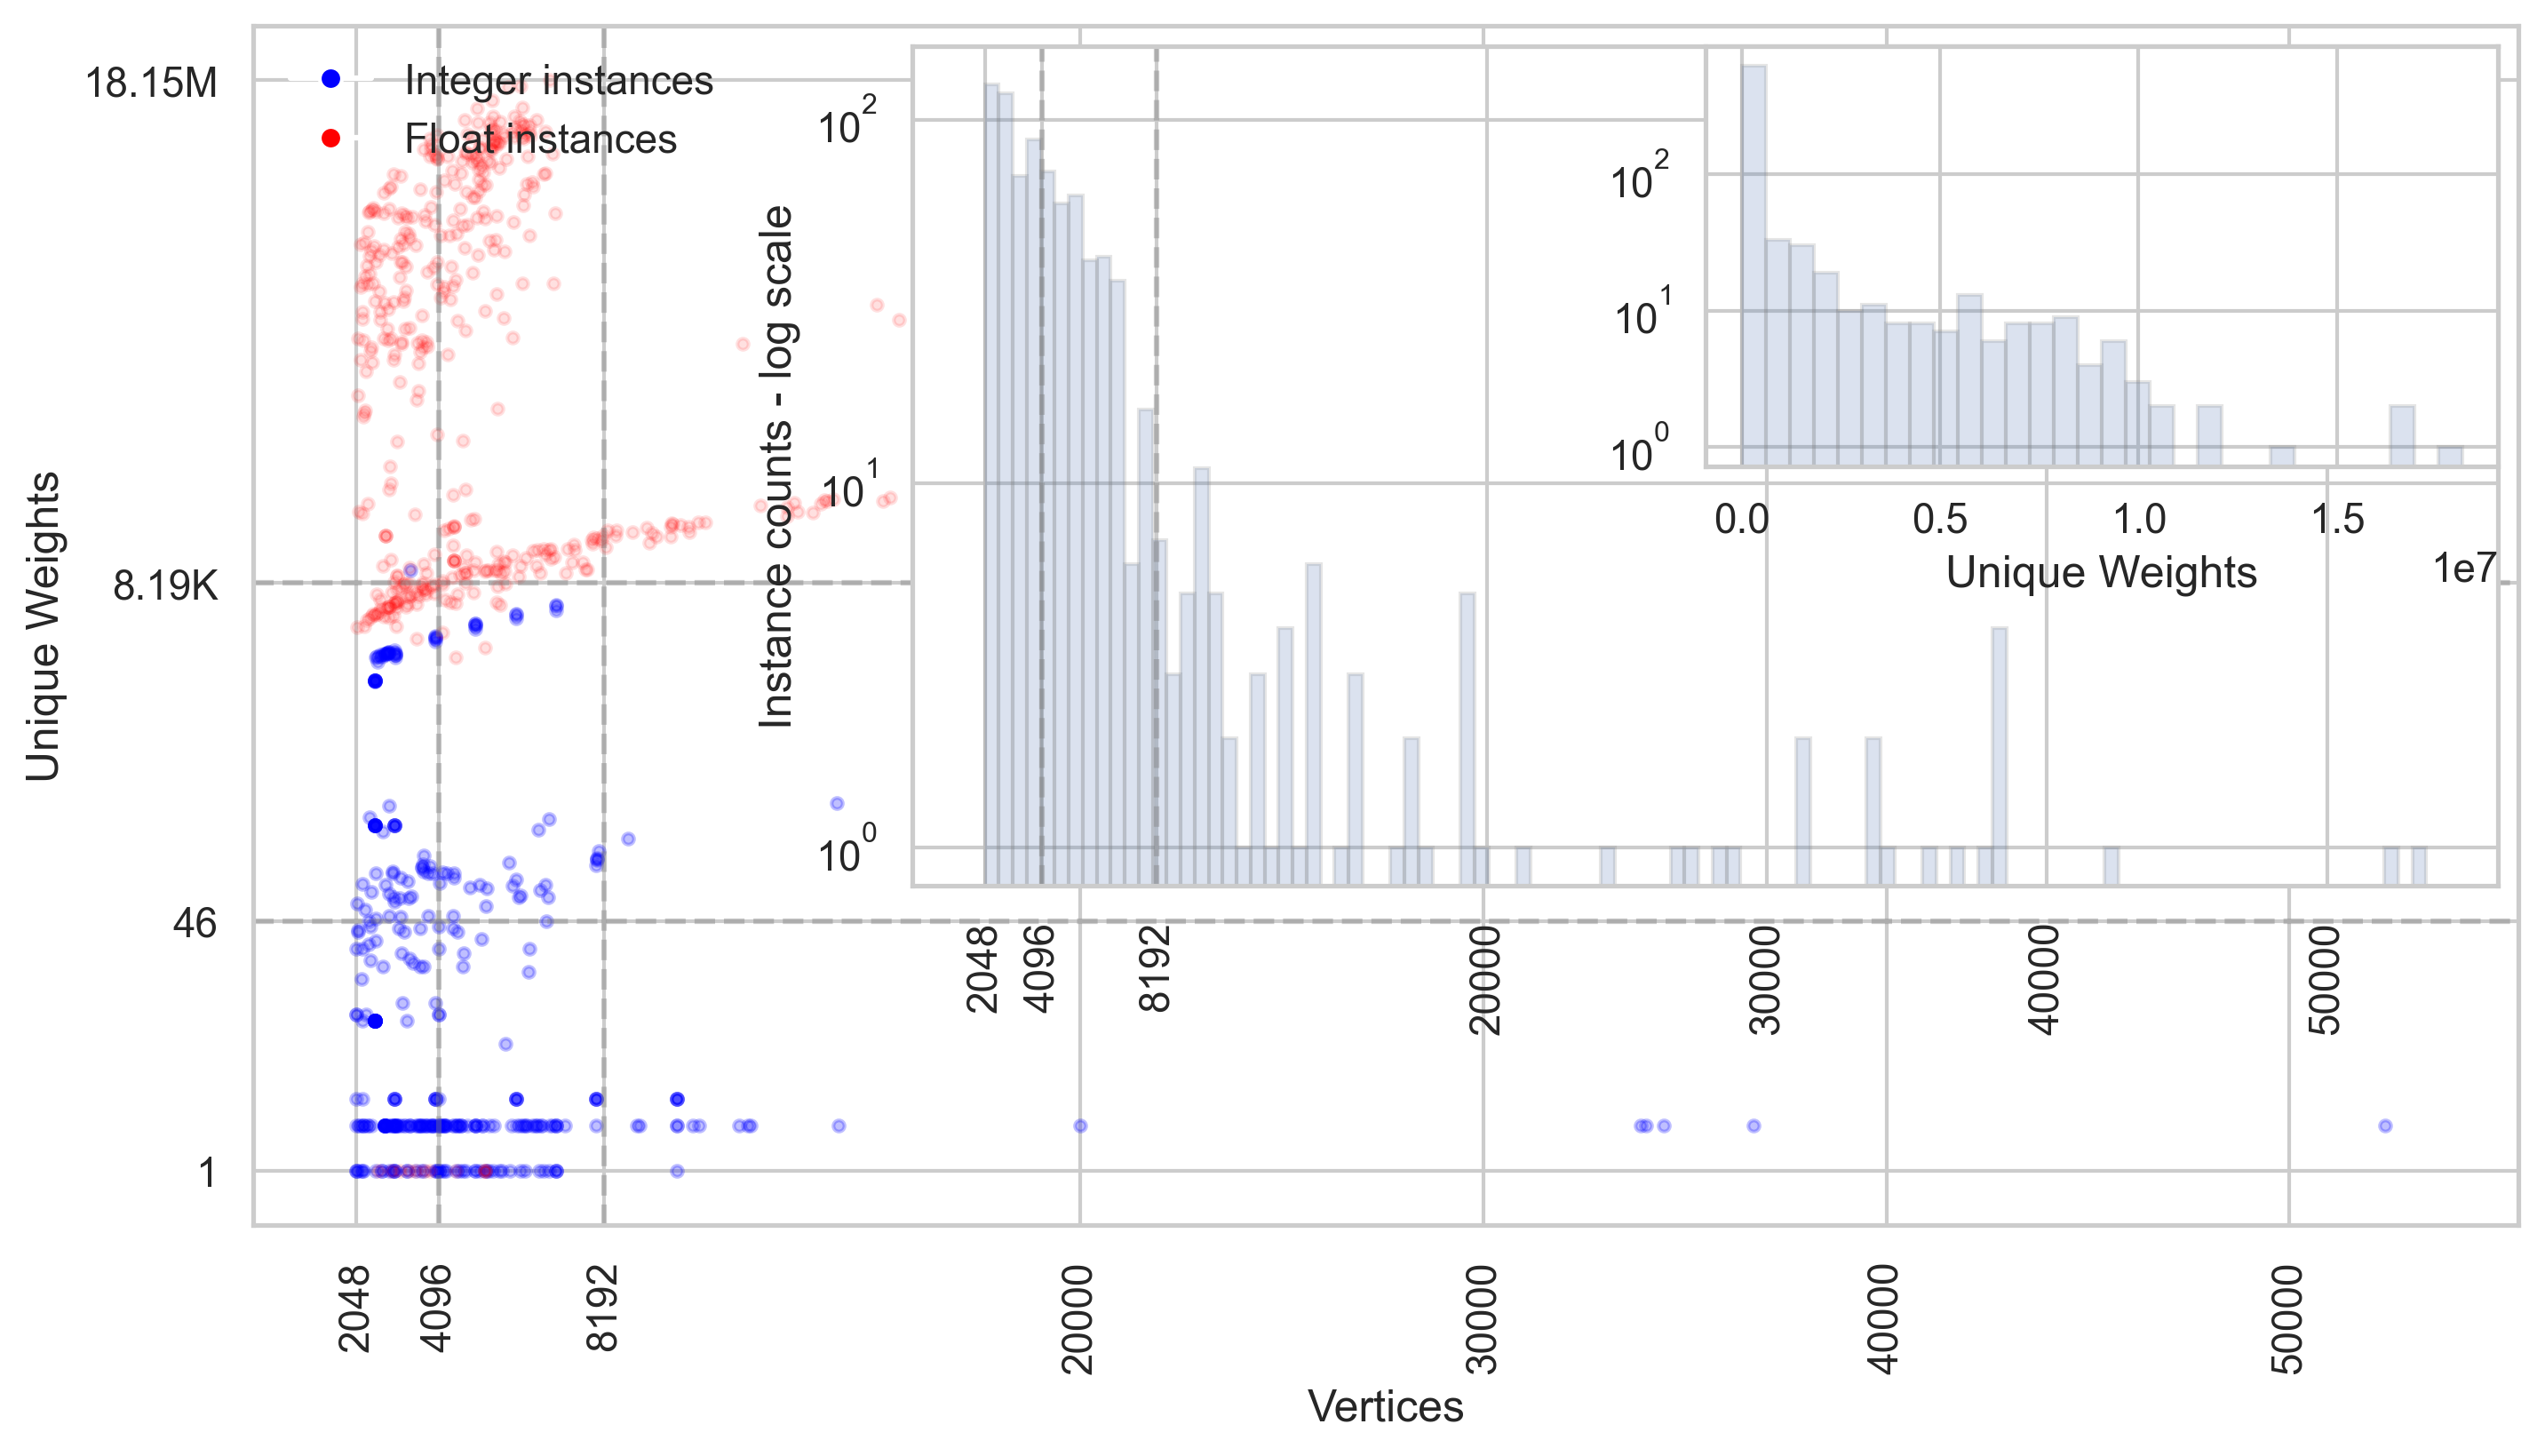

In [165]:
plotting.plot_edge_weight_distribution(df_filter,nodes_col="nodes_x",unique_weights_col="unique_weights",int_only_col="int_only",file_name='Unique weight-density distribution.png')

In [166]:
df_filter["unique_ratio"] = (
    df_filter["unique_weights"] / df_filter["edges_x"]
)

In [177]:
df_filter = df_filter.dropna(subset=cfg.SOLVERS)

In [168]:
df_filter['size_cat'].value_counts()

size_cat
medium    407
large     331
Name: count, dtype: int64

In [169]:
df_filter['density_cat'].value_counts()

density_cat
sparse      450
balanced    197
dense        91
Name: count, dtype: int64

In [170]:
df_filter['int_only'].value_counts()

int_only
False    389
True     349
Name: count, dtype: int64

In [171]:
len(df_filter)

738

In [184]:
df_int = df_filter[df_filter["int_only"] == True]
df_float = df_filter[df_filter["int_only"] == False]

In [185]:
df_float['weight_frequency_category'].value_counts()

weight_frequency_category
highly_diverse    378
uniform            11
Name: count, dtype: int64

In [186]:
# allU- all weights unique
# gt75 - unique ratio greater than 0.75
# gt95 - unique ratio greater than 0.95
# uniform - all the instances are unique

df_float["weight_frequency_category"] = df_float.apply(
    lambda row: utils.classify_float_weight_structure(
        row["unique_ratio"],
        row["unique_weights"]
    ),
    axis=1
)
df_float["weight_frequency_category"].value_counts()

weight_frequency_category
gt95       207
allU       157
gt75        14
uniform     11
Name: count, dtype: int64

In [187]:
df_int["weight_frequency_category"] = df_int.apply(
    lambda row: utils.classify_weight_structure(
        row["n_weights_90"],
        row["unique_weights"]
    ),
    axis=1
)

In [188]:
df_int["n_weights_90"].describe()

count     349.000000
mean      169.260745
std       677.198899
min         1.000000
25%         2.000000
50%         8.000000
75%        61.000000
max      8985.000000
Name: n_weights_90, dtype: float64

In [189]:
df_int['weight_frequency_category'].value_counts()

weight_frequency_category
strongly_repeated    123
highly_diverse       104
weakly_repeated       73
uniform               49
Name: count, dtype: int64

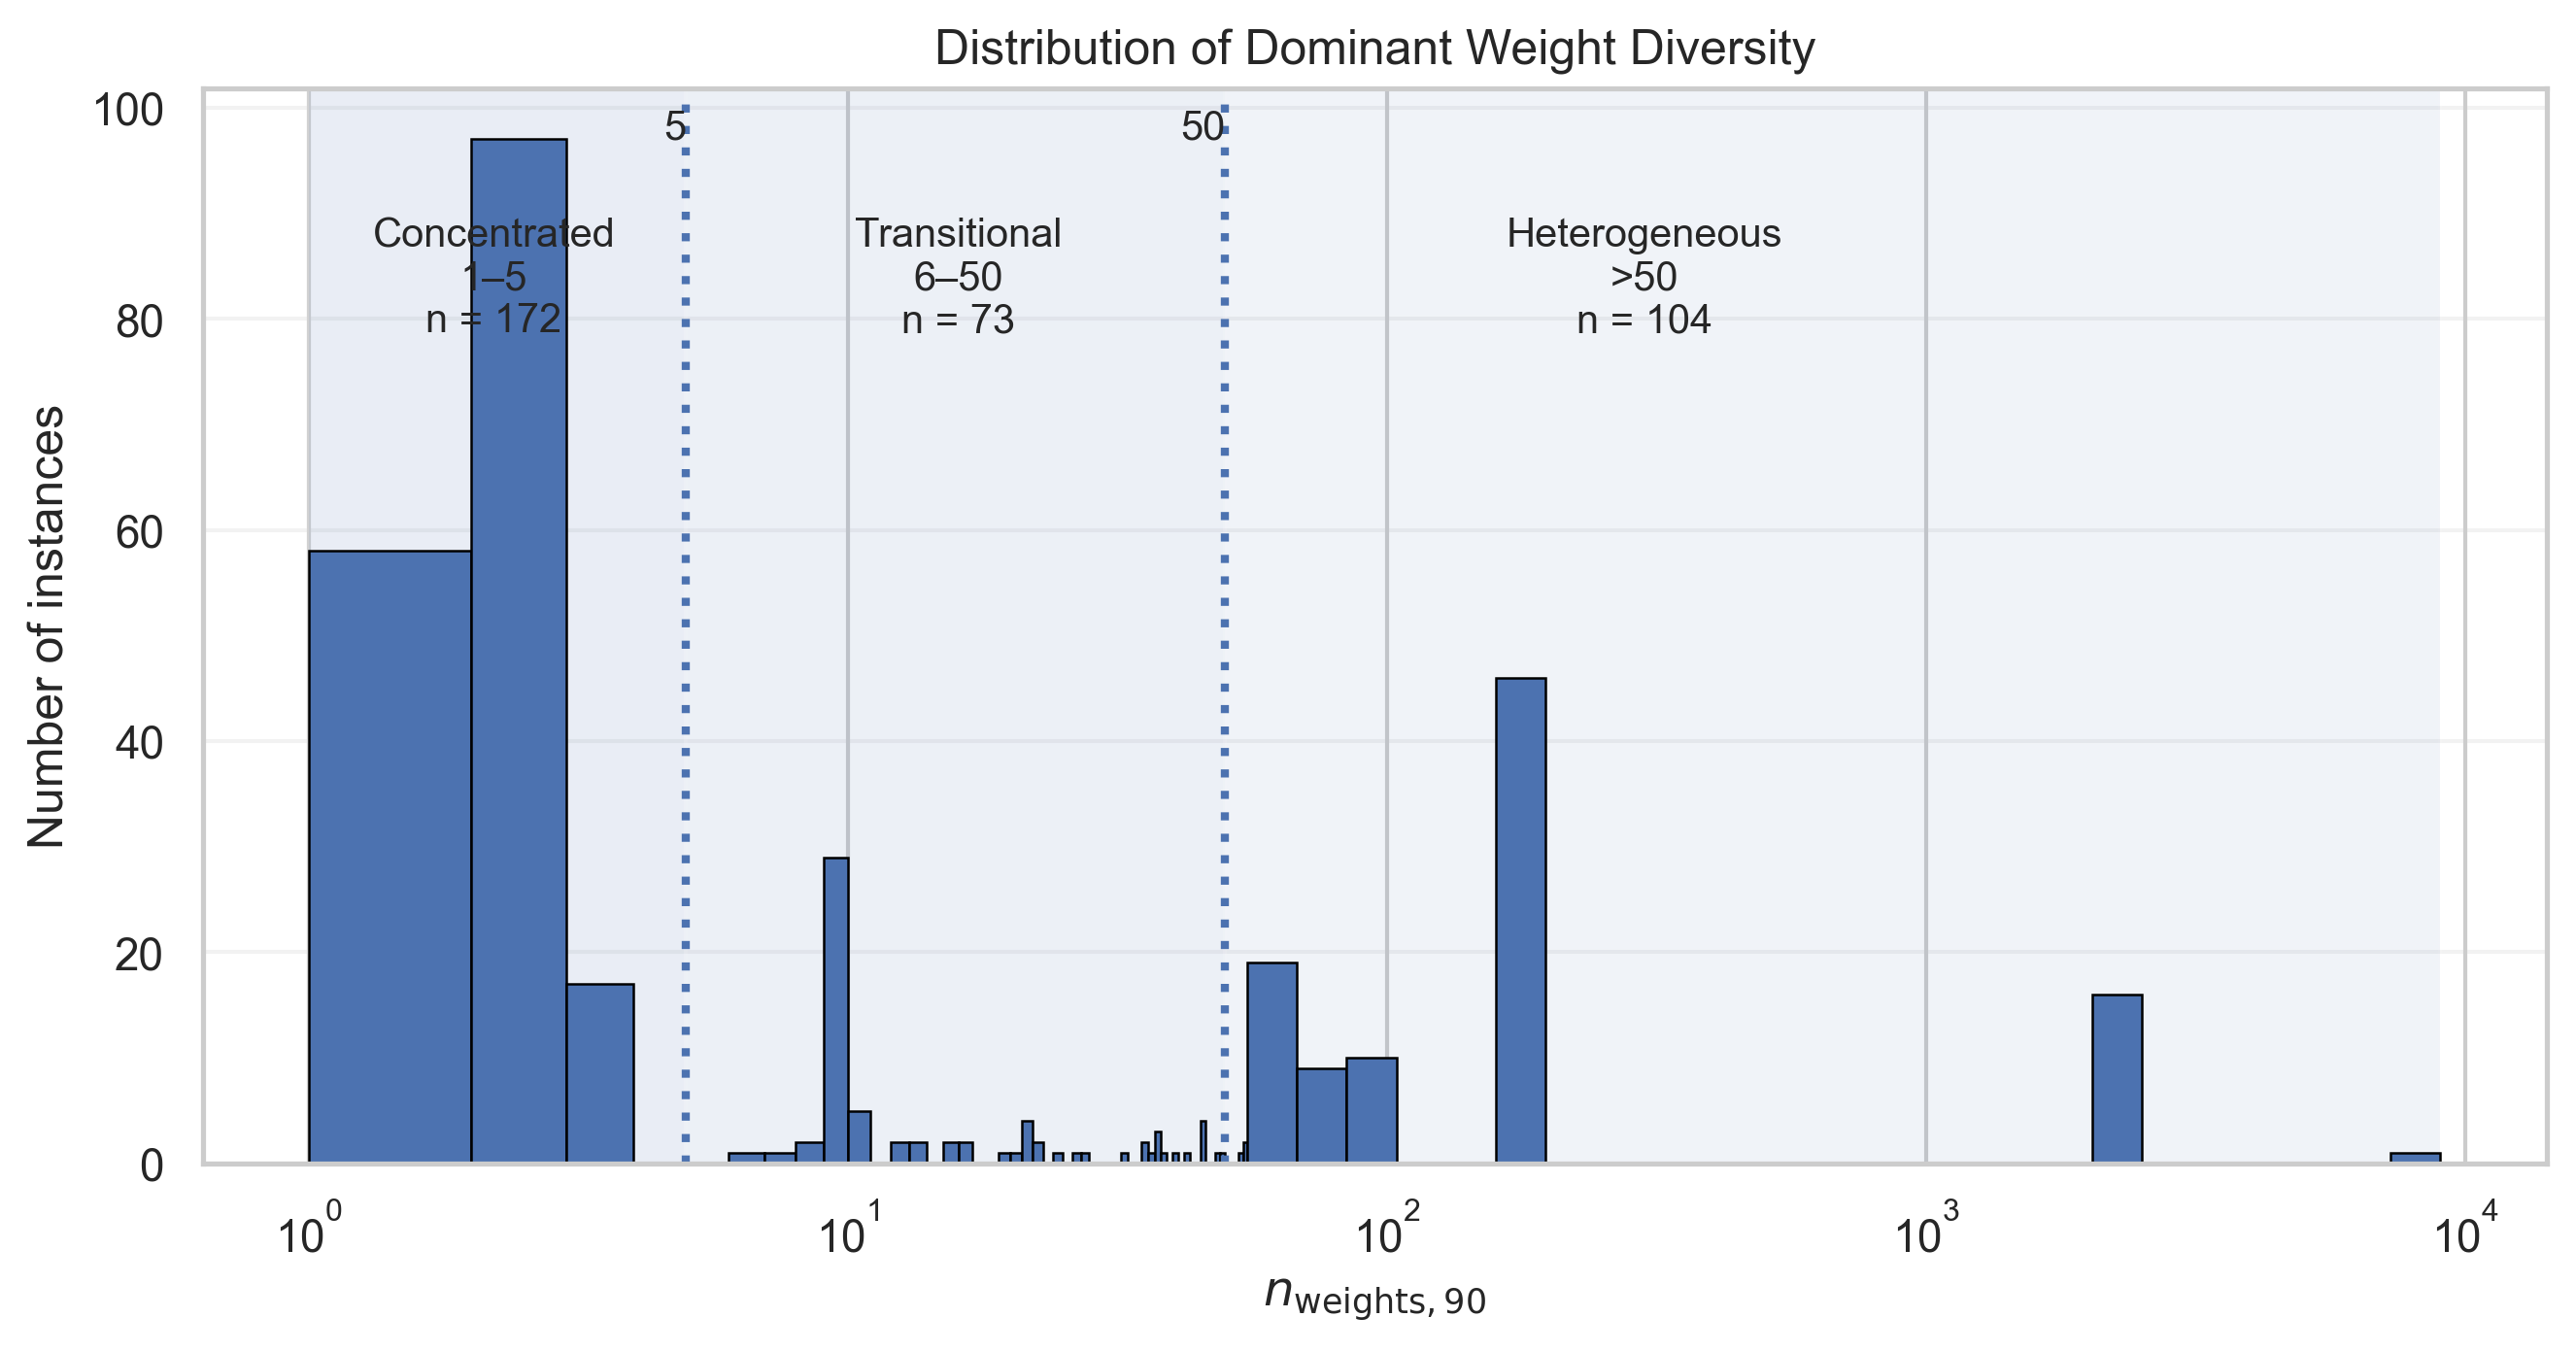

In [190]:
plotting.plot_n_weights_90_histogram(
    df_int,
    file_name="n_weights_90_histogram.pdf"
)

In [191]:
df_int[df_int['weight_frequency_category']=='uniform']['size_cat'].value_counts()

size_cat
large     27
medium    22
Name: count, dtype: int64

In [192]:
df_int[df_int['weight_frequency_category']=='strongly_repeated']['size_cat'].value_counts()

size_cat
medium    67
large     56
Name: count, dtype: int64

In [193]:
df_int[df_int['weight_frequency_category']=='weakly_repeated']['size_cat'].value_counts()

size_cat
medium    54
large     19
Name: count, dtype: int64

In [194]:
df_int[df_int['weight_frequency_category']=='highly_diverse']['size_cat'].value_counts()

size_cat
medium    74
large     30
Name: count, dtype: int64

In [195]:
results = []

for category, group in df_int.groupby("weight_frequency_category"):

    n = len(group)

    row = {
        "weight_frequency_category": category,
        "n": n
    }

    for solver in cfg.SOLVERS:

        hits = (group[solver] == group["baseline_objective"]).sum()

        pct_hits = (hits / n) * 100

        row[solver] = pct_hits

    results.append(row)

summary_df = pd.DataFrame(results)

summary_df["weight_frequency_category"] = pd.Categorical(
    summary_df["weight_frequency_category"],
    categories=cfg.CATEGORY_ORDER_UW,
    ordered=True
)

summary_df = summary_df.sort_values(
    "weight_frequency_category"
).reset_index(drop=True)

summary_df

,weight_frequency_category,n,DAv2,DAv3,DAv3c,heuristic
0,uniform,49,36.734694,100.000000,59.183673,40.816327
1,strongly_repeated,123,51.219512,97.560976,30.894309,25.203252
2,weakly_repeated,73,30.136986,84.931507,24.657534,15.068493
3,highly_diverse,104,51.923077,75.961538,31.730769,23.076923


In [196]:
from statsmodels.stats.proportion import proportion_confint

results = []

for category, group in df_int.groupby("weight_frequency_category"):

    n = len(group)

    row = {
        "weight_frequency_category": category,
        "n": n
    }

    for solver in cfg.SOLVERS:

        successes = (group[solver] == group["baseline_objective"]).sum()
        proportion = successes / n

        ci_low, ci_high = proportion_confint(
            successes,
            n,
            alpha=0.05,
            method="wilson"
        )

        row[f"{solver}_pct"] = proportion * 100
        row[f"{solver}_ci_low"] = ci_low * 100
        row[f"{solver}_ci_high"] = ci_high * 100


    results.append(row)

ci_table = pd.DataFrame(results)

ci_table["weight_frequency_category"] = pd.Categorical(
    summary_df["weight_frequency_category"],
    categories=cfg.CATEGORY_ORDER_UW,
    ordered=True
)

ci_table = ci_table.sort_values(
    "weight_frequency_category"
).reset_index(drop=True)

ci_table

,weight_frequency_category,n,DAv2_pct,DAv2_ci_low,DAv2_ci_high,DAv3_pct,DAv3_ci_low,DAv3_ci_high,DAv3c_pct,DAv3c_ci_low,DAv3c_ci_high,heuristic_pct,heuristic_ci_low,heuristic_ci_high
0,uniform,104,51.923077,42.424498,61.284651,75.961538,66.918886,83.154621,31.730769,23.573154,41.189934,23.076923,16.026407,32.045512
1,strongly_repeated,123,51.219512,42.483722,59.881435,97.560976,93.074040,99.167094,30.894309,23.411077,39.534792,25.203252,18.361090,33.547379
2,weakly_repeated,49,36.734694,24.665173,50.732932,100.000000,92.730218,100.000000,59.183673,45.247319,71.784761,40.816327,28.215239,54.752681
3,highly_diverse,73,30.136986,20.822591,41.437366,84.931507,74.998098,91.372323,24.657534,16.204465,35.644445,15.068493,8.627677,25.001902


In [156]:
# DAv3 vs DAv2
dav3_vs_dav2 = utils.pairwise_win_tie_loss_by_weight_category(
    df_int_filter,
    solver_a="DAv3",
    solver_b="DAv2"
)
dav3_vs_heu = utils.pairwise_win_tie_loss_by_weight_category(
    df_int_filter,
    solver_a="DAv3",
    solver_b="heuristic"
)

# DAv3c vs heuristic
dav3c_vs_heuristic = utils.pairwise_win_tie_loss_by_weight_category(
    df_int_filter,
    solver_a="DAv3c",
    solver_b="heuristic"
)

# DAv3 vs DAv3c
dav3_vs_dav3c = utils.pairwise_win_tie_loss_by_weight_category(
    df_int_filter,
    solver_a="DAv3",
    solver_b="DAv3c"
)

dav3_vs_dav2

,category,n,DAv3_wins,ties,DAv2_wins,DAv3_win_pct,tie_pct,DAv2_win_pct
0,highly_diverse,104,50,29,25,48.076923,27.884615,24.038462
1,strongly_repeated,123,60,60,3,48.780488,48.780488,2.439024
2,uniform,49,31,18,0,63.265306,36.734694,0.000000
3,weakly_repeated,73,50,17,6,68.493151,23.287671,8.219178


In [157]:
dav3_vs_dav3c

,category,n,DAv3_wins,ties,DAv3c_wins,DAv3_win_pct,tie_pct,DAv3c_win_pct
0,highly_diverse,104,54,33,17,51.923077,31.730769,16.346154
1,strongly_repeated,123,84,38,1,68.292683,30.894309,0.813008
2,uniform,49,20,29,0,40.816327,59.183673,0.000000
3,weakly_repeated,73,55,12,6,75.342466,16.438356,8.219178


In [158]:
dav3_vs_heu

,category,n,DAv3_wins,ties,heuristic_wins,DAv3_win_pct,tie_pct,heuristic_win_pct
0,highly_diverse,104,64,23,17,61.538462,22.115385,16.346154
1,strongly_repeated,123,92,31,0,74.796748,25.203252,0.000000
2,uniform,49,29,20,0,59.183673,40.816327,0.000000
3,weakly_repeated,73,61,11,1,83.561644,15.068493,1.369863


In [159]:
dav3c_vs_heuristic 

,category,n,DAv3c_wins,ties,heuristic_wins,DAv3c_win_pct,tie_pct,heuristic_win_pct
0,highly_diverse,104,37,19,48,35.576923,18.269231,46.153846
1,strongly_repeated,123,57,28,38,46.341463,22.764228,30.894309
2,uniform,49,18,20,11,36.734694,40.816327,22.448980
3,weakly_repeated,73,31,11,31,42.465753,15.068493,42.465753


In [160]:
dav3c_vs_dav2 = utils.pairwise_win_tie_loss_by_weight_category(
    df_int_filter,
    solver_a="DAv3c",
    solver_b="DAv2"
)
dav3c_vs_dav2

,category,n,DAv3c_wins,ties,DAv2_wins,DAv3c_win_pct,tie_pct,DAv2_win_pct
0,highly_diverse,104,25,11,68,24.038462,10.576923,65.384615
1,strongly_repeated,123,6,33,84,4.878049,26.829268,68.292683
2,uniform,49,15,14,20,30.612245,28.571429,40.816327
3,weakly_repeated,73,14,11,48,19.178082,15.068493,65.753425


In [161]:
dav2_vs_heu = utils.pairwise_win_tie_loss_by_weight_category(
    df_int_filter,
    solver_a="DAv2",
    solver_b="heuristic"
)
dav2_vs_heu

,category,n,DAv2_wins,ties,heuristic_wins,DAv2_win_pct,tie_pct,heuristic_win_pct
0,highly_diverse,104,76,8,20,73.076923,7.692308,19.230769
1,strongly_repeated,123,90,30,3,73.170732,24.390244,2.439024
2,uniform,49,27,12,10,55.102041,24.489796,20.408163
3,weakly_repeated,73,51,10,12,69.863014,13.698630,16.438356


In [201]:
df_final = df_final[df_final["limit"] > cfg.MIN_TIME_LIMIT]
df_final = df_final.dropna(subset=cfg.SOLVERS)
df_final_int = df_final[df_final["int_only"] == True]

In [205]:
len(df_final_int)

1205

In [202]:
df_final_int["unique_ratio"] = (
    df_final_int["unique_weights"] / df_final_int["edges_x"]
)
df_final_int["weight_frequency_category"] = df_final_int.apply(
    lambda row: utils.classify_weight_structure(
        row["n_weights_90"],
        row["unique_weights"]
    ),
    axis=1
)

In [204]:
results = []

for category, group in df_final_int.groupby("weight_frequency_category"):

    n = len(group)

    row = {
        "weight_frequency_category": category,
        "n": n
    }

    for solver in cfg.SOLVERS:

        hits = (group[solver] == group["baseline_objective"]).sum()

        pct_hits = (hits / n) * 100

        row[solver] = pct_hits

    results.append(row)

summary_df = pd.DataFrame(results)


summary_df["weight_frequency_category"] = pd.Categorical(
    summary_df["weight_frequency_category"],
    categories=cfg.CATEGORY_ORDER_UW,
    ordered=True
)

summary_df = summary_df.sort_values(
    "weight_frequency_category"
).reset_index(drop=True)

summary_df

,weight_frequency_category,n,DAv2,DAv3,DAv3c,heuristic
0,uniform,173,76.878613,100.000000,73.988439,53.757225
1,strongly_repeated,335,68.955224,92.537313,50.746269,36.119403
2,weakly_repeated,461,52.060738,80.043384,54.880694,32.754881
3,highly_diverse,236,72.033898,74.152542,47.881356,36.864407
